In [17]:
import pandas as pd

# Load CSV files
pop = pd.read_csv("../data_raw/population_2001_zone_corrected.csv")
literacy = pd.read_csv("../data_raw/literacy_2001_zone_corrected.csv")
tech = pd.read_csv("../data_raw/tech_access_2001_zone_corrected.csv")

# Merge population with literacy
df = pd.merge(pop, literacy, on=["Zone","District"], how="left")

# Merge with tech access
df = pd.merge(df, tech, on=["Zone","District"], how="left")

# Check the resulting DataFrame
print("Shape:", df.shape)  # should show 16 rows (8 districts * Urban+Rural)
print(df)

df.to_csv('../data_processed/df_2001.csv', index=False)



Shape: (16, 15)
          Zone   District Urban_Rural  Total_Population   Male  Female  \
0     Janakpur   Dhanusha       Urban             86000  43000   43000   
1     Janakpur   Dhanusha       Rural            146000  73000   73000   
2     Janakpur  Mahottari       Urban             61000  30500   30500   
3     Janakpur  Mahottari       Rural            131000  65500   65500   
4     Janakpur    Sarlahi       Urban             66000  33000   33000   
5     Janakpur    Sarlahi       Rural            136000  68000   68000   
6     Narayani       Bara       Urban             92000  46000   46000   
7     Narayani       Bara       Rural            158000  79000   79000   
8     Narayani      Parsa       Urban             96000  48000   48000   
9     Narayani      Parsa       Rural            154000  77000   77000   
10    Narayani   Rautahat       Urban             71000  35500   35500   
11    Narayani   Rautahat       Rural            142000  71000   71000   
12  Sagarmatha     Sir

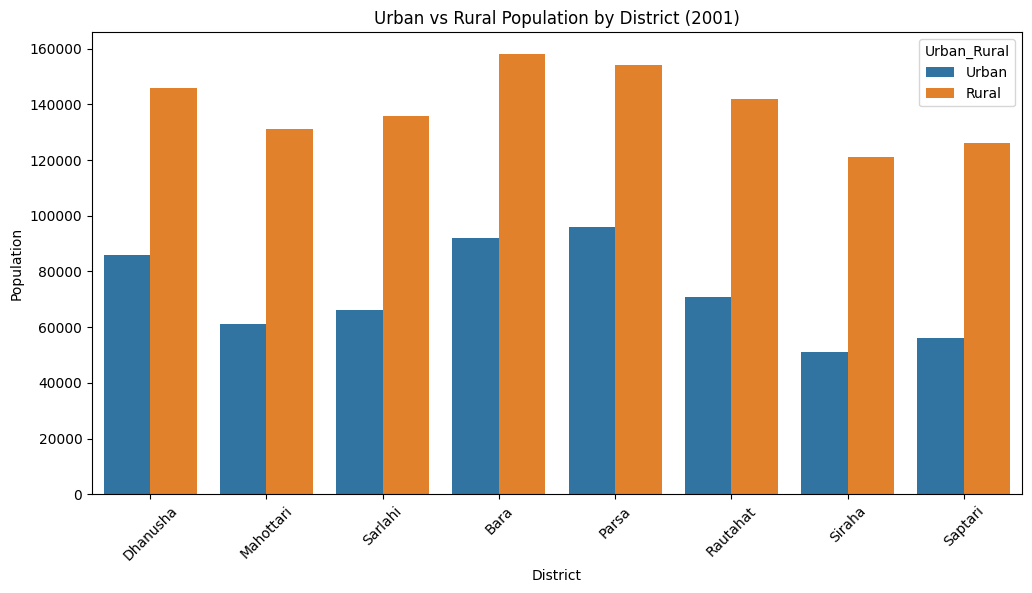

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Urban vs Rural population
plt.figure(figsize=(12,6))
sns.barplot(x='District', y='Total_Population', hue='Urban_Rural', data=df)
plt.title('Urban vs Rural Population by District (2001)')
plt.ylabel('Population')
plt.xlabel('District')
plt.xticks(rotation=45)
plt.show()


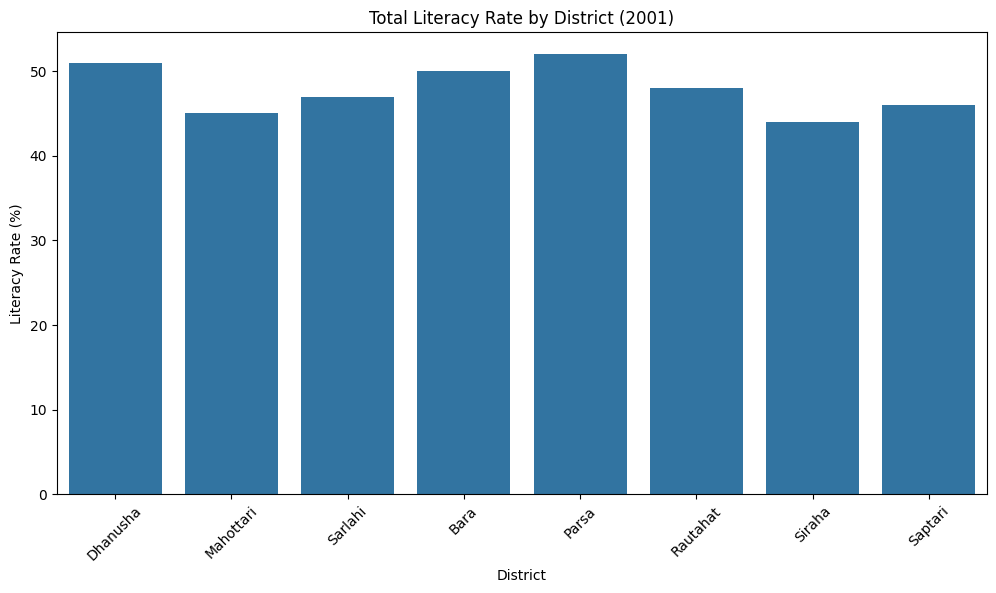

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(x='District', y='Literacy_Rate_Total', data=df.drop_duplicates('District'))
plt.title('Total Literacy Rate by District (2001)')
plt.ylabel('Literacy Rate (%)')
plt.xlabel('District')
plt.xticks(rotation=45)
plt.show()


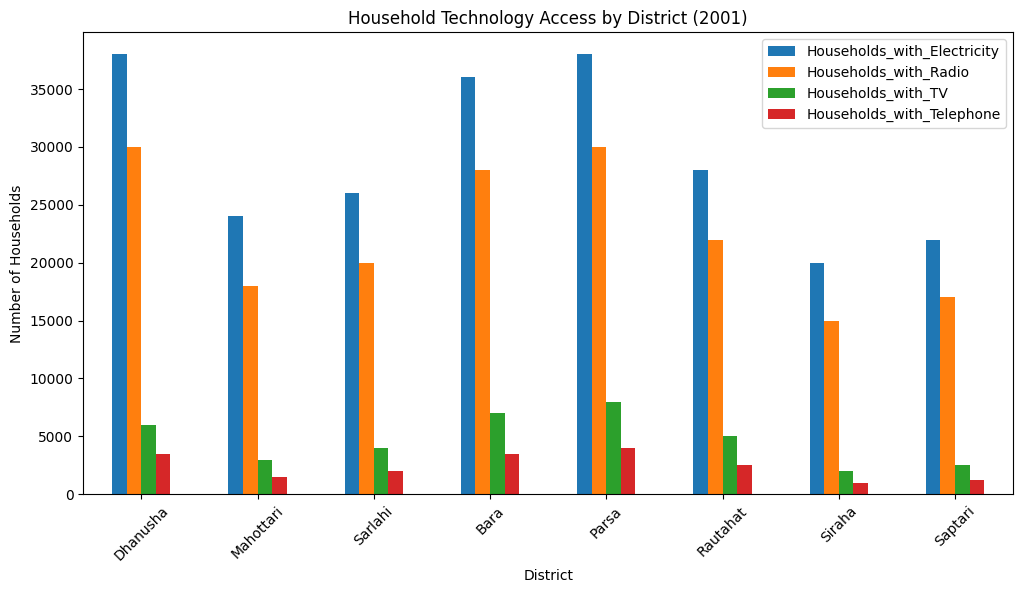

In [7]:
tech_cols = ['Households_with_Electricity','Households_with_Radio','Households_with_TV','Households_with_Telephone']
tech_summary = df.drop_duplicates('District')[['District'] + tech_cols].set_index('District')

tech_summary.plot(kind='bar', figsize=(12,6))
plt.title('Household Technology Access by District (2001)')
plt.ylabel('Number of Households')
plt.xticks(rotation=45)
plt.show()


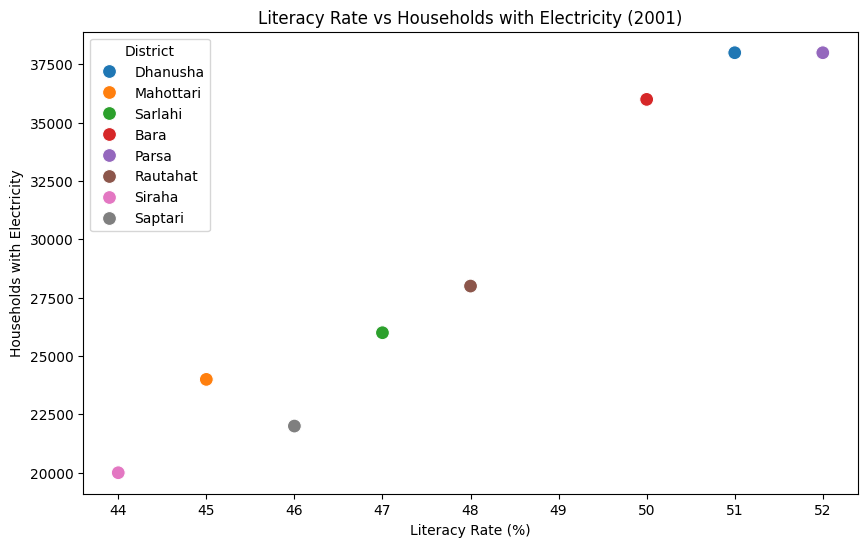

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Literacy_Rate_Total',
    y='Households_with_Electricity',
    hue='District',
    data=df.drop_duplicates('District'),
    s=100
)
plt.title('Literacy Rate vs Households with Electricity (2001)')
plt.xlabel('Literacy Rate (%)')
plt.ylabel('Households with Electricity')
plt.show()


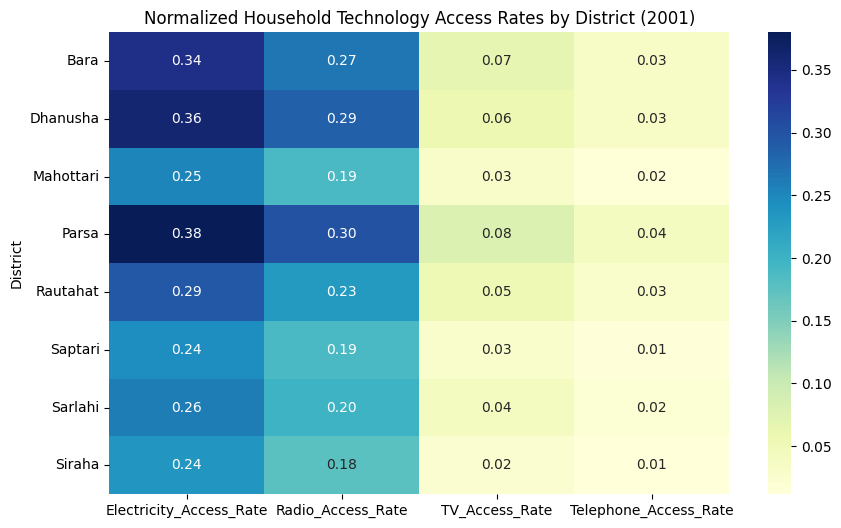

In [ ]:
#heatmap 
import matplotlib.pyplot as plt
import seaborn as sns

# Take unique districts and mean across Urban/Rural
df_district = df.groupby('District')[['Electricity_Access_Rate','Radio_Access_Rate','TV_Access_Rate','Telephone_Access_Rate']].mean()

# Normalize to 0-1 scale
df_normalized = df_district / 100

plt.figure(figsize=(10,6))
sns.heatmap(df_normalized, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Normalized Household Technology Access Rates by District (2001)')
plt.show()




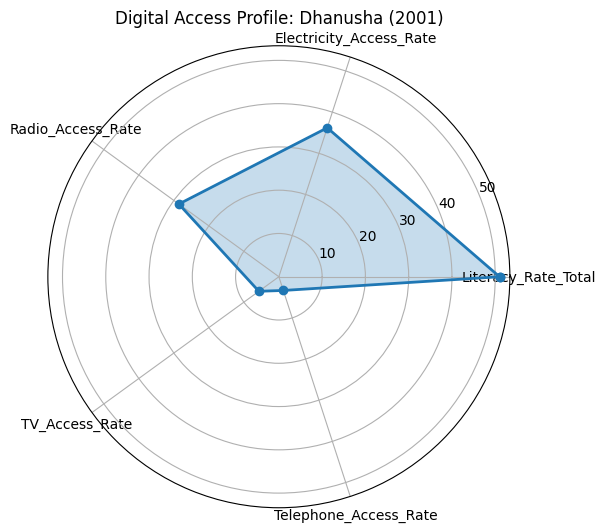

In [ ]:
#radarchart for one district dhanusha
import matplotlib.pyplot as plt 
import numpy as np

district = 'Dhanusha'
metrics = ['Literacy_Rate_Total','Electricity_Access_Rate','Radio_Access_Rate','TV_Access_Rate','Telephone_Access_Rate']
values = df[df['District']==district][metrics].mean().values
values = np.append(values, values[0])  # close the radar chart

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, values, 'o-', linewidth=2)
ax.fill(angles, values, alpha=0.25)
ax.set_thetagrids(angles[:-1]*180/np.pi, metrics)
plt.title(f'Digital Access Profile: {district} (2001)')
plt.show()



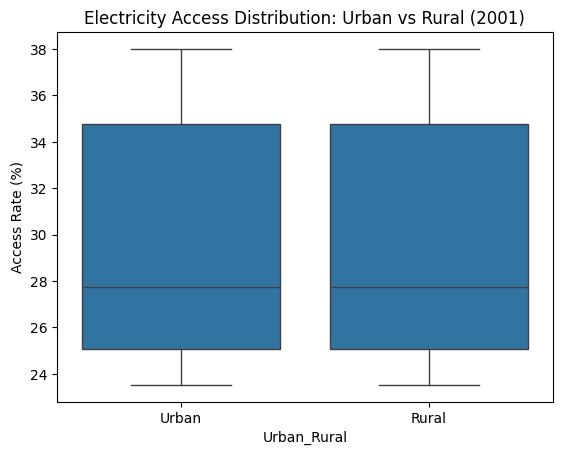

In [ ]:
#boxplot
sns.boxplot(x='Urban_Rural', y='Electricity_Access_Rate', data=df)
plt.title('Electricity Access Distribution: Urban vs Rural (2001)')
plt.ylabel('Access Rate (%)')
plt.show()

